In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [59]:
caminho_arquivo = '/content/drive/MyDrive/visualizacao/League of Legends Champion Stats 12.1.csv'

In [60]:
df = pd.read_csv(caminho_arquivo, sep=';')

In [61]:
df.columns

Index(['Name', 'Class', 'Role', 'Tier', 'Score', 'Trend', 'Win %', 'Role %',
       'Pick %', 'Ban %', 'KDA'],
      dtype='object')

In [62]:
df['Name'] = df['Name'] + ' (' + df['Role'] + ')'

In [63]:
# Converte Win % e Pick % para número
if 'Win %' in df.columns and df['Win %'].dtype == object:
    df['Win %'] = df['Win %'].str.replace('%', '').astype(float)

if 'Pick %' in df.columns and df['Pick %'].dtype == object:
    df['Pick %'] = df['Pick %'].str.replace('%', '').astype(float)

if 'Ban %' in df.columns and df['Ban %'].dtype == object:
    df['Ban %'] = df['Ban %'].str.replace('%', '').astype(float)

In [64]:
df['NIVEL_BAN'] = pd.cut(
    df['Ban %'],
    bins=[-np.inf, 5.0, 15.0, np.inf],
    labels=['Baixo', 'Médio', 'Alto']
)

In [65]:
coluna_ordenacao = 'Win %'

df_sorted = df.sort_values(by=coluna_ordenacao, ascending=False).reset_index(drop=True)

In [66]:
colunas_vis = [
    'Name',
    'NIVEL_BAN',
    'Win %',
    'KDA',
    'Pick %'
]

tipos_vis = [
    'nominal',
    'ordinal',
    'quantitativa',
    'quantitativa',
    'quantitativa']

In [67]:
cores_ordinais = {
    'Baixo': '#ff9999',
    'Médio': '#ffcc99',
    'Alto': '#66b3ff'
}

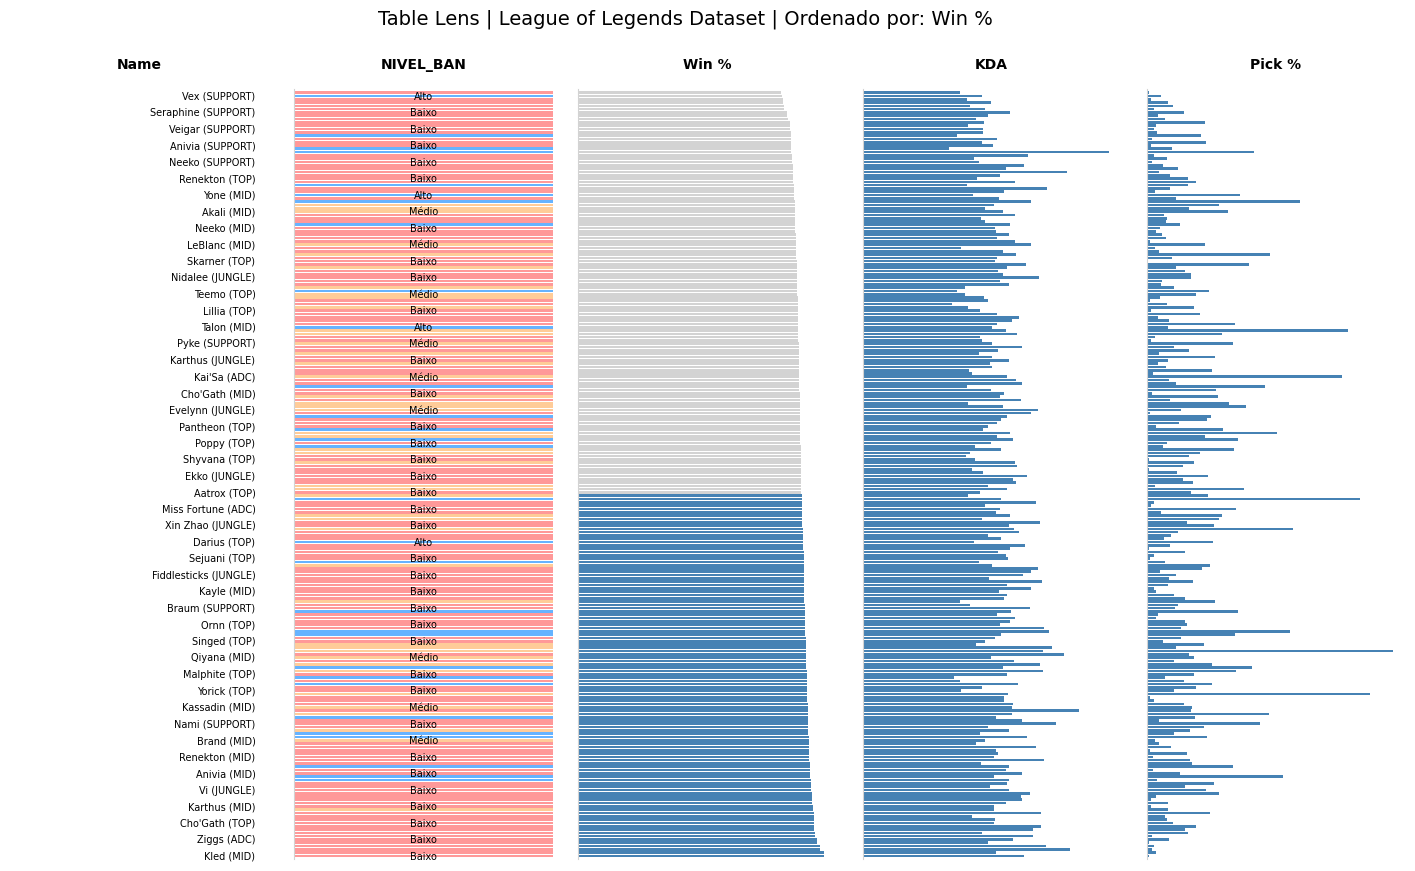

In [68]:
fig, axes = plt.subplots(nrows=1, ncols=len(colunas_vis), figsize=(18, 10), sharey=True)
plt.subplots_adjust(wspace=0.1)

y_pos = np.arange(len(df_sorted))

limite_foco = 50.0

for i, (col, tipo) in enumerate(zip(colunas_vis, tipos_vis)):
    ax = axes[i]

    if tipo == 'quantitativa':
      if col == 'Win %':
            cores = ['steelblue' if v >= limite_foco else 'lightgray' for v in df_sorted[col]]
      else:
            cores = 'steelblue'

      ax.barh(y_pos, df_sorted[col], color=cores, height=0.8)
      ax.set_xticks([])

    elif tipo == 'ordinal':
        cores = df_sorted[col].map(cores_ordinais).tolist()
        ax.barh(y_pos, [1]*len(df_sorted), color=cores, height=0.8)
        ax.set_xticks([])
        ax.set_xlim(0, 1)

        for j, val in enumerate(df_sorted[col]):
            if j % 5 == 0:
                ax.text(0.5, j, str(val), ha='center', va='center', fontsize=7, color='black')

    elif tipo == 'nominal':
        ax.barh(y_pos, [1]*len(df_sorted), color='white')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(0, 1)

        for j, val in enumerate(df_sorted[col]):
            if j % 5 == 0:
                ax.text(0.95, j, str(val), ha='right', va='center', fontsize=7, color='black')

        ax.spines['left'].set_visible(False)

    ax.set_title(col, fontsize=10, fontweight='bold', pad=15)
    ax.set_ylim(-1, len(df_sorted))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if tipo != 'nominal':
        ax.spines['left'].set_color('lightgray')

plt.suptitle(f'Table Lens | League of Legends Dataset | Ordenado por: {coluna_ordenacao}', fontsize=14, y=0.96)
plt.savefig('table_lens_lol.png', dpi=300, bbox_inches='tight')

plt.show()
